<a href="https://colab.research.google.com/github/karri-ten/LENET-MODEL-USING-SUBSET-OF-MNIST/blob/main/LENET_model_using_a_2_class_subset_of_the_MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2><b>LENET model using a 2-class subset of the MNIST dataset</b></h2>

<h3> Steps Overview</h3>

Load MNIST data

Filter for classes 3 and 5

Preprocess data (normalize, reshape, one-hot encode)

Build LeNet architecture

Compile and train the model

Evaluate the model




In [2]:
# Load MNIST data
!pip install torch torchvision matplotlib

In [5]:
# Import Libaries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt


**Preprocessing and Dataset Filtering**

In [6]:
# Define transform (resize to 32x32 and convert to tensor)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

# Load dataset
train_dataset_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_full = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Filter for digits 3 and 5
def filter_dataset(dataset):
    idx = np.where((np.array(dataset.targets) == 3) | (np.array(dataset.targets) == 5))[0]
    dataset.targets = dataset.targets[idx]
    dataset.data = dataset.data[idx]

    # Relabel: 3 -> 0, 5 -> 1
    dataset.targets = torch.where(dataset.targets == 3, torch.tensor(0), torch.tensor(1))
    return dataset

train_dataset = filter_dataset(train_dataset_full)
test_dataset = filter_dataset(test_dataset_full)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.76MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.32MB/s]


**LeNet Architecture using PyTorch**

In [7]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 2)  # binary classification

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x


setup training

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LeNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


**Taining loop**

In [9]:
def train(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / len(loader), correct / total


In [ ]:
def load_images():
    """Load filtered images (digits 3 and 5) from torchvision datasets."""

    transform = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])

    # Load full MNIST datasets
    train_set_full = datasets.MNIST(PATH_DATASET, download=True, train=True, transform=transform)
    val_set_full = datasets.MNIST(PATH_DATASET, download=True, train=False, transform=transform)

    def filter_dataset(dataset):
        # Only keep labels 3 and 5
        idx = (dataset.targets == 3) | (dataset.targets == 5)
        dataset.targets = dataset.targets[idx]
        dataset.data = dataset.data[idx]

        # Map: 3 -> 0, 5 -> 1
        dataset.targets = torch.where(dataset.targets == 3, torch.tensor(0), torch.tensor(1))
        return dataset

    train_set = filter_dataset(train_set_full)
    val_set = filter_dataset(val_set_full)

    train_data = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
    validation_data = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

    return train_data, validation_data


**Evaluation Function**

In [10]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0
    correct = 0
    loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return loss / len(loader), correct / total


**Run trained dataset**

In [13]:
num_epochs = 30
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")


Epoch 1/30 | Train Acc: 0.9946, Test Acc: 0.9932
Epoch 2/30 | Train Acc: 0.9927, Test Acc: 0.9947
Epoch 3/30 | Train Acc: 0.9964, Test Acc: 0.9905
Epoch 4/30 | Train Acc: 0.9953, Test Acc: 0.9937
Epoch 5/30 | Train Acc: 0.9965, Test Acc: 0.9947
Epoch 6/30 | Train Acc: 0.9960, Test Acc: 0.9953
Epoch 7/30 | Train Acc: 0.9959, Test Acc: 0.9974
Epoch 8/30 | Train Acc: 0.9974, Test Acc: 0.9953
Epoch 9/30 | Train Acc: 0.9976, Test Acc: 0.9937
Epoch 10/30 | Train Acc: 0.9975, Test Acc: 0.9942
Epoch 11/30 | Train Acc: 0.9981, Test Acc: 0.9953
Epoch 12/30 | Train Acc: 0.9991, Test Acc: 0.9921
Epoch 13/30 | Train Acc: 0.9991, Test Acc: 0.9942
Epoch 14/30 | Train Acc: 0.9977, Test Acc: 0.9958
Epoch 15/30 | Train Acc: 0.9984, Test Acc: 0.9953
Epoch 16/30 | Train Acc: 0.9995, Test Acc: 0.9953
Epoch 17/30 | Train Acc: 0.9997, Test Acc: 0.9947
Epoch 18/30 | Train Acc: 0.9985, Test Acc: 0.9953
Epoch 19/30 | Train Acc: 0.9994, Test Acc: 0.9953
Epoch 20/30 | Train Acc: 0.9994, Test Acc: 0.9963
Epoch 21/

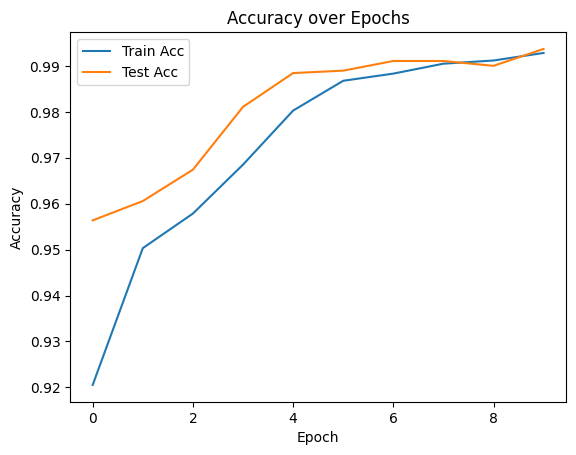

In [12]:
plt.plot(train_accs, label="Train Acc")
plt.plot(test_accs, label="Test Acc")
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
